# Exploration de la qualité des données

Nous devons vérifier si les données collectées sont suffisamment fiables et pertinentes pour notre sujet.

## Partie A : Import de fonctions utiles à l'exploration qualité

Avant de procéder à l'acquisition des données, il est essentiel de configurer notre environnement de travail. Dans une optique de **reproductibilité** et de **clarté du code**, la logique technique (les fonctions de téléchargement) a été déportée dans un dossier dédié nommé `/fonctions/exploration`, composé de fichiers Python. 

La cellule suivante initialise cette connexion en ajoutant le dossier des scripts au chemin système de Python et en important l'ensemble des dépendances nécessaires.

In [ ]:
import sys
import os
import pandas as pd
from pathlib import Path

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions/exploration
sys.path.insert(0, os.path.abspath("../fonctions/exploration"))

%load_ext autoreload
%autoreload 2

# On importe toutes les fonctions dans le fichier imports.py
from transfermarkt import *
from fbref import *
from statsbomb import *
from football_data import *
from soccerdata import *
from blessures import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Partie B : Exploration qualité de chaque source de données

### B1 : Les données Transfermarkt

Avant d'intégrer les statistiques de performance, il est impératif de valider la fiabilité de notre variable cible : la **valeur marchande**. 
Cette phase permet de comprendre la structure du marché, d'identifier les segments de joueurs et de nettoyer les données pour garantir la précision du futur modèle prédictif.

#### B1.1 : Source des données et traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores)
* **Identifiant :** `davidcariboo/player-scores`

Nous vérifions tout d'abord que les données récoltées sont sufissamment récentes.

In [32]:
identifiant = "davidcariboo/player-scores"
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : davidcariboo/player-scores
Dernière mise à jour : 2026-08-05 07:19:00.543000


#### B1.2 : Analyse exploratoire de la population

L'examen initial des distributions révèle trois facteurs principaux concernant la valorisation des joueurs :

* **Distribution des valeurs marchandes :** On observe un comportement assez particulier. La majorité des joueurs se situe sous les 5M€, tandis que très peu de joueurs dépassent les 100M€.
* **Courbe des âges :** La distribution suit une courbe de Gauss centrée sur **24-28 ans**. La valeur marchande étant liée au potentiel de revente et à la qualité physique, l'âge sera une variable explicative non-linéaire majeure.
* **Segmentation par ligue (Big 5) :** Les boxplots confirment un marché à plusieurs vitesses. La **Premier League** affiche non seulement la médiane la plus haute mais aussi la plus forte concentration de joueurs plus chers (les outliers). À talent égal, le facteur "Ligue" devrait influencer drastiquement le prix final.

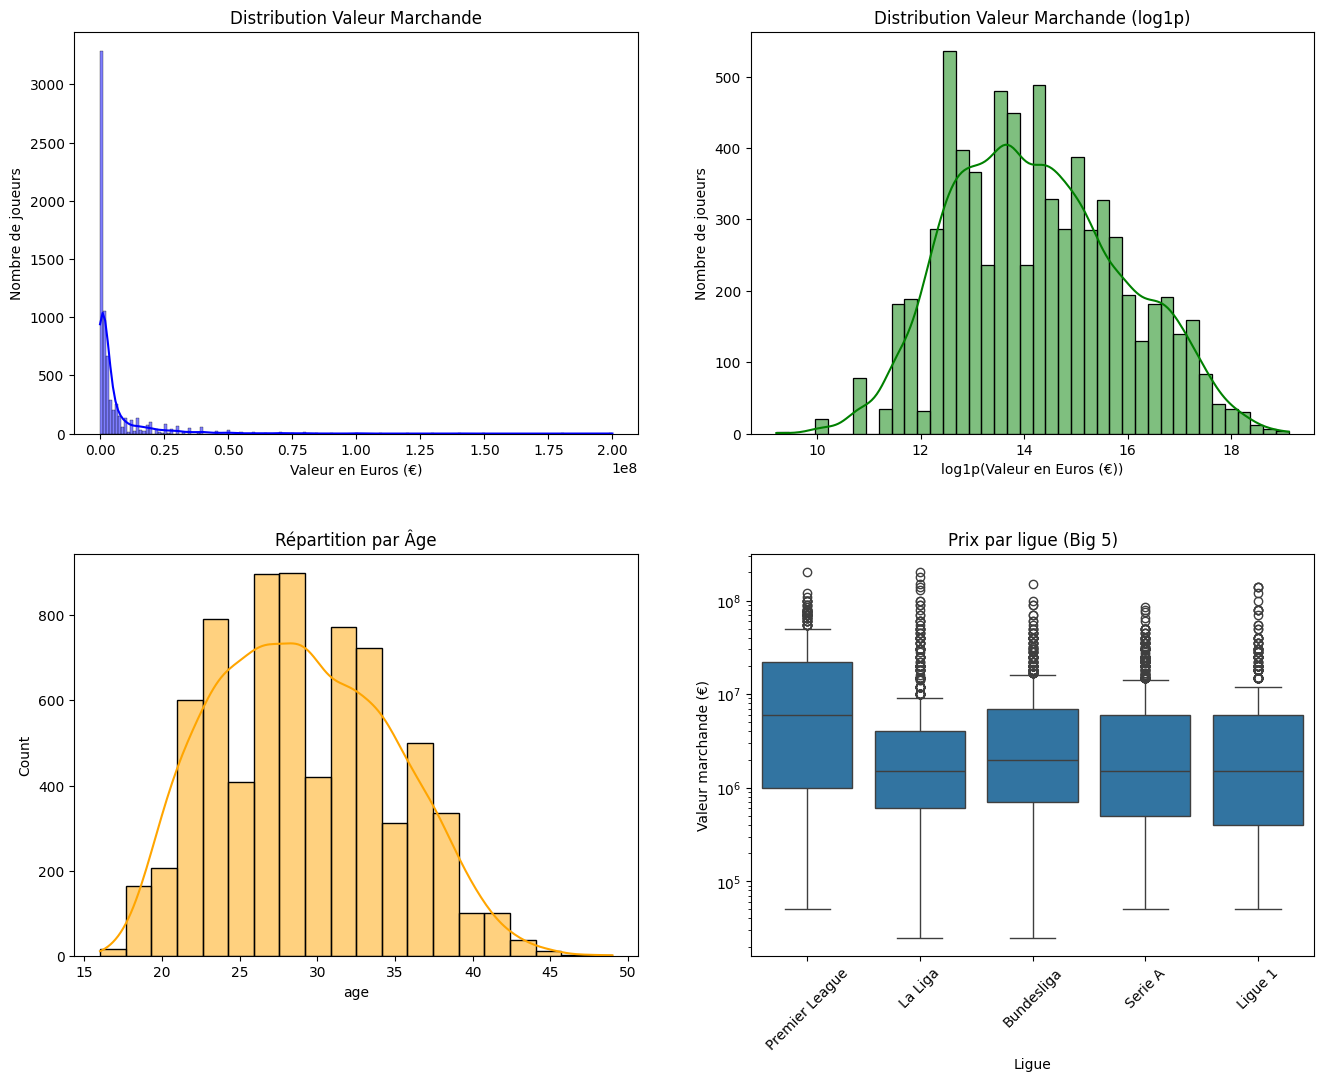

In [33]:
# Chargement des fichiers
df_players = pd.read_csv("../data/transfermarkt_datasets/players.csv")
df_clubs = pd.read_csv("../data/transfermarkt_datasets/clubs.csv")

# Exploration des données
plot_transfermarkt_quality(df_players, df_clubs)

#### B1.3 : Fraîcheur et pertinence temporelle

Le graphique des dates de dernières évaluations est un indicateur de fiabilité. En effet, une partie du dataset contient des prix n'ayant pas été mis à jour depuis plusieurs années (2012-2022). Ces données ne sont plus analysables statistiquement car elles ne correspondent plus aux performances actuelles.

Nombre total d'évaluations dans l'historique : 45467
Nombre de joueurs uniques évalués : 5570
Date de l'évaluation la plus ancienne (historique) : 2019-07-01
Date de l'évaluation la plus récente (marché actuel) : 2026-03-27


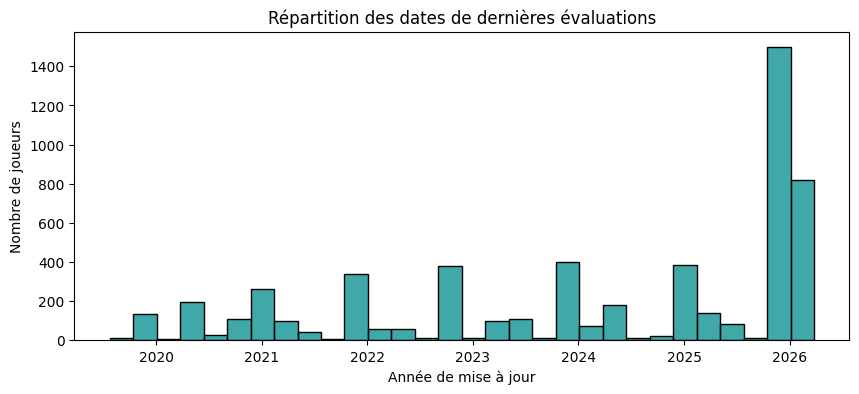

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
3,540659,2019-07-24,500000,FC Girondins Bordeaux,200,NL1
4,465715,2019-07-25,250000,FC Nantes,995,FR1
79,353959,2019-09-10,300000,RCD Espanyol B,59358,SER1
130,77760,2019-09-12,15000000,Tottenham Hotspur,148,GB1
114,37981,2019-09-12,2500000,Watford FC,410,IT1
...,...,...,...,...,...,...
45358,649026,2026-03-27,6000000,Paris FC,10004,FR1
45359,651973,2026-03-27,600000,Le Havre AC,738,FR1
45360,655006,2026-03-27,25000000,RC Strasbourg Alsace,667,FR1
45362,658536,2026-03-27,25000000,AS Monaco,162,FR1


In [14]:
# Chargement de l'historique des valeurs marchandes
df_valuations = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

# Exploration de l'historique des valeurs marchandes
get_latest_player_valuations(df_valuations, plot_freshness=True)

#### B1.4 : Diagnostic de l'intégrité des données

Le nettoyage technique repose sur trois vérifications critiques :

* **Valeurs manquantes (NaN) :** 18% des joueurs n'ont pas de valeur cible (valeur marchande) et sont donc exclus. Les statistiques internationales manquantes sont imputées à `0` (joueurs non-sélectionnés).
* **Doublons :** Seuls 2 doublons (Nom/Date de naissance) ont été détectés, prouvant la robustesse du dataset.
* **Intégrité référentielle (orphelins) :** 135 joueurs possèdent un historique de prix mais aucune fiche de profil associée.

Complétude globale - Valeurs manquantes par colonne
Taux de complétude initial (toutes variables) : 91.34%
Taux de complétude après retrait des variables > 20% de NA : 99.05%
4 variables retirées  : agent_name, international_caps, international_goals, current_national_team_id


c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\exploration\transfermarkt.py:275: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct_plot.index, y=missing_pct_plot.values, palette="Reds_r")


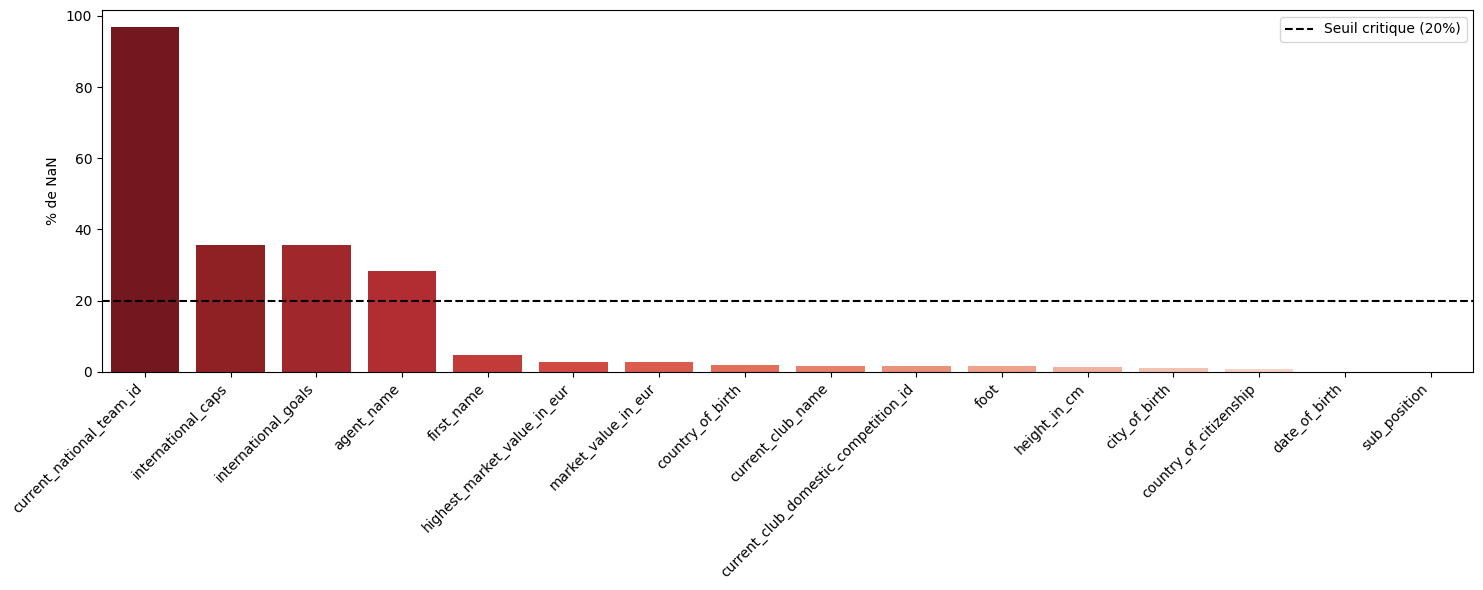

In [15]:
# Analyse des valeurs manquantes
df_players = df_players.drop(columns = ['contract_expiration_date'])
check_all_missing_values(df_players)

In [7]:
# Analyse des doublons

check_player_duplicates(df_players)

Aucun doublon de joueur détecté sur le combo nom/date de naissance.


In [8]:
# On vérifie l'intégrité avant d'aller plus loin

df_market_final = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

orphans_list = check_referential_integrity(df_players, df_market_final)

Analyse de l'intégrité référentielle :
Joueurs dans le fichier Profil : 7306
Joueurs dans le fichier Valuations : 5570
161 joueurs ont des prix mais n'ont pas de profil.


#### B1.5 Granularité de la valeur marchande

Nous vérifions ici que les valeurs marchandes sont mises à jour régulièrement.

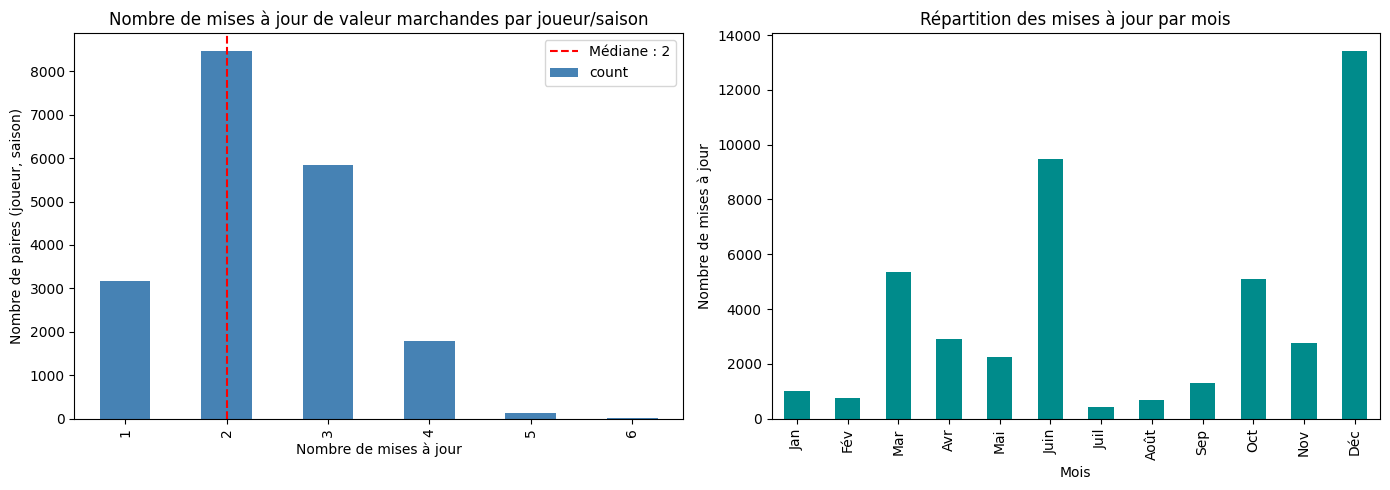

Statistiques sur les mises à jour par joueur/saison :
    Médiane  : 2
    Moyenne  : 2.34
    Max      : 6
    1 seule mise à jour     : 3,160 paires joueur/saison (16.3%)
    2 mises à jour          : 8,462 paires joueur/saison (43.6%)
    3 mises à jour ou plus  : 7,767 paires joueur/saison (40.1%)


In [9]:
# Diagnostic de la fréquence des mises à jour des valeurs marchandes

updates = audit_valuation_frequency(df_market_final)

Agrégation 'latest' terminée :
  Lignes avant : 45,467
  Lignes après : 19,389  (1 valeur marchande par joueur/saison)
  Joueurs uniques : 5,570
Agrégation 'mean' terminée :
  Lignes avant : 45,467
  Lignes après : 19,389  (1 valeur marchande par joueur/saison)
  Joueurs uniques : 5,570
Agrégation 'max' terminée :
  Lignes avant : 45,467
  Lignes après : 19,389  (1 valeur marchande par joueur/saison)
  Joueurs uniques : 5,570


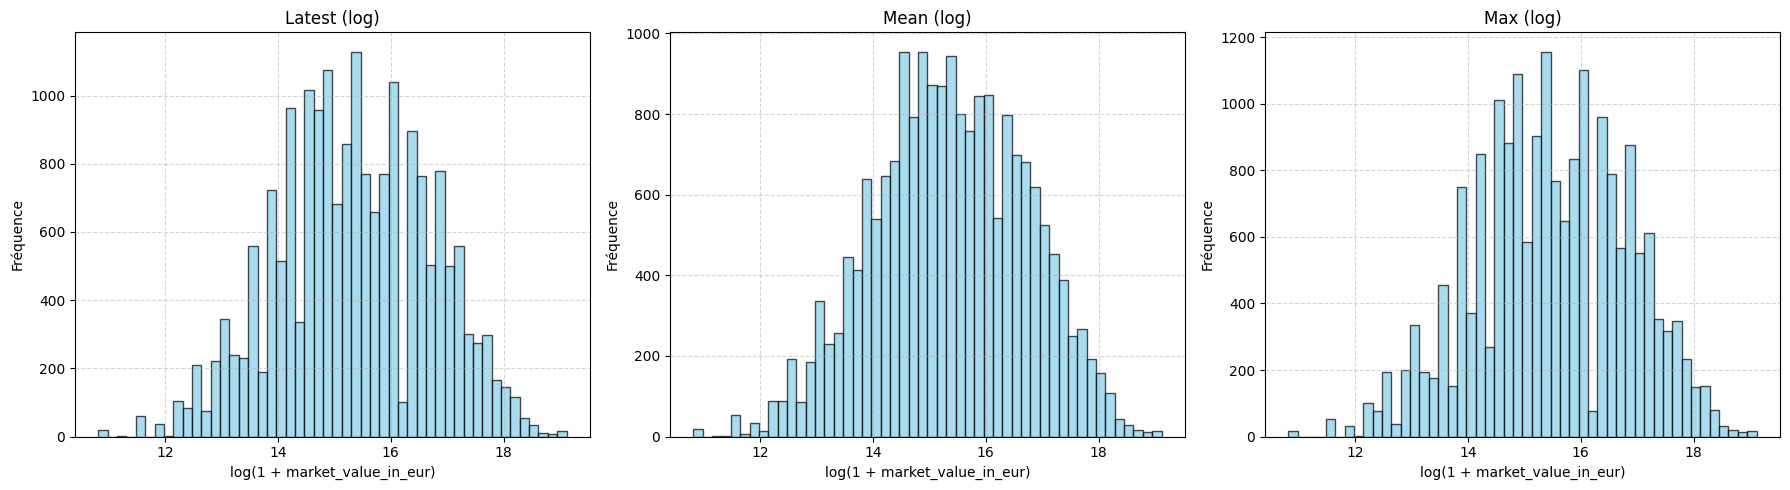

In [10]:
# Agrégation pour avoir une seule valeur : dernière valeur marchande pour chaque saison
df_valuations_season = aggregate_valuations_by_season(df_valuations, method='latest')

# Comparons avec les autres méthodes (moyenne et maximale des valeurs marchandes pour chaque saison)
df_val_mean = aggregate_valuations_by_season(df_valuations, method='mean')
df_val_max  = aggregate_valuations_by_season(df_valuations, method='max')

plot_log_valuations(df_valuations_season, df_val_mean, df_val_max)

### B2 : Les données Soccerdata

#### B2.1 : Séparation du dataset

Nous avons dans un premier temps séparé les joueurs de champ des gardiens afin que nos analyses aient du sens, car certaines colonnes du dataset ne concernent que les gardiens et d'autres ne concernent que les joueurs de champ.
Nous avons au final 15 888 joueurs de champ et 1 225 gardiens.

In [41]:
# Chargement des données
df_soccerdata = pd.read_csv("../data/soccerdata/data_final_soccerdata.csv")

# Séparation joueurs de champ / gardiens
df_field, df_gk = split_field_gk(df_soccerdata)
print(f"Joueurs de champ : {len(df_field):,}  |  Gardiens : {len(df_gk):,}")

Joueurs de champ : 15,888  |  Gardiens : 1,225


#### B2.2 : Analyse des valeurs manquantes

L'analyse globale montre une forte disparité dans la complétude des données selon les catégories statistiques.

* **Données critiques à 100% de NaN :** Les colonnes liées aux penaltys (`Penalty Kicks_PKatt`, `Performance_PKcon`, etc.) et aux statistiques spécifiques des gardiens présentes par erreur dans le profil des joueurs de champ sont totalement vides.
* **Statistiques avancées (xG) :** On observe un palier autour de **50% de valeurs manquantes** pour les métriques de création (`xg_buildup`, `np_xg`, `xa`).

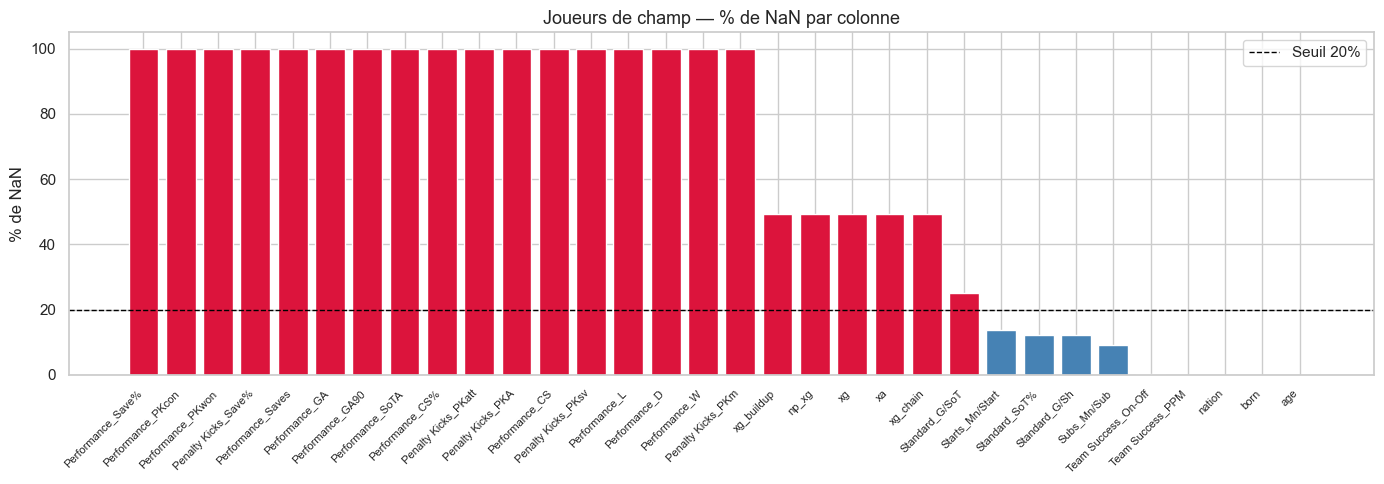

23 colonne(s) au-dessus du seuil 20% :
  Performance_Save%                             100.0%
  Performance_PKcon                             100.0%
  Performance_PKwon                             100.0%
  Penalty Kicks_Save%                           100.0%
  Performance_Saves                             100.0%
  Performance_GA                                100.0%
  Performance_GA90                              100.0%
  Performance_SoTA                              100.0%
  Performance_CS%                               100.0%
  Penalty Kicks_PKatt                           100.0%
  Penalty Kicks_PKA                             100.0%
  Performance_CS                                100.0%
  Penalty Kicks_PKsv                            100.0%
  Performance_L                                 100.0%
  Performance_D                                 100.0%
  Performance_W                                 100.0%
  Penalty Kicks_PKm                             100.0%
  xg_buildup              

In [42]:
# Valeurs manquantes globales pour les joueurs de champ
missing_global = audit_missing_values(df_field, title="Joueurs de champ")

#### B2.3 : Couverture des variables clés

Cet audit vérifie la disponibilité des variables jugées essentielles pour la modélisation de la performance.

* Toutes les variables d'Expected Goals (`xg`, `xa`, `np_xg`, `xg_chain`) présentent un manque de données significatif. Cela est peut-être dû au fait que les joueurs ne tirent pas tous au but.
* Les colonnes de temps de jeu (`Min`, `MP`), de performance brute (`Gls`, `Ast`) et les métriques défensives (`TklW`, `Int`) sont parfaitement renseignées.
* **Disponibilité :** Les statistiques spécifiques aux gardiens de buts (`Save%`, `CS%`) affichent un très faible taux de manquants (inférieur à 5%). Cela valide l'utilisation du dataset pour ces joueurs.

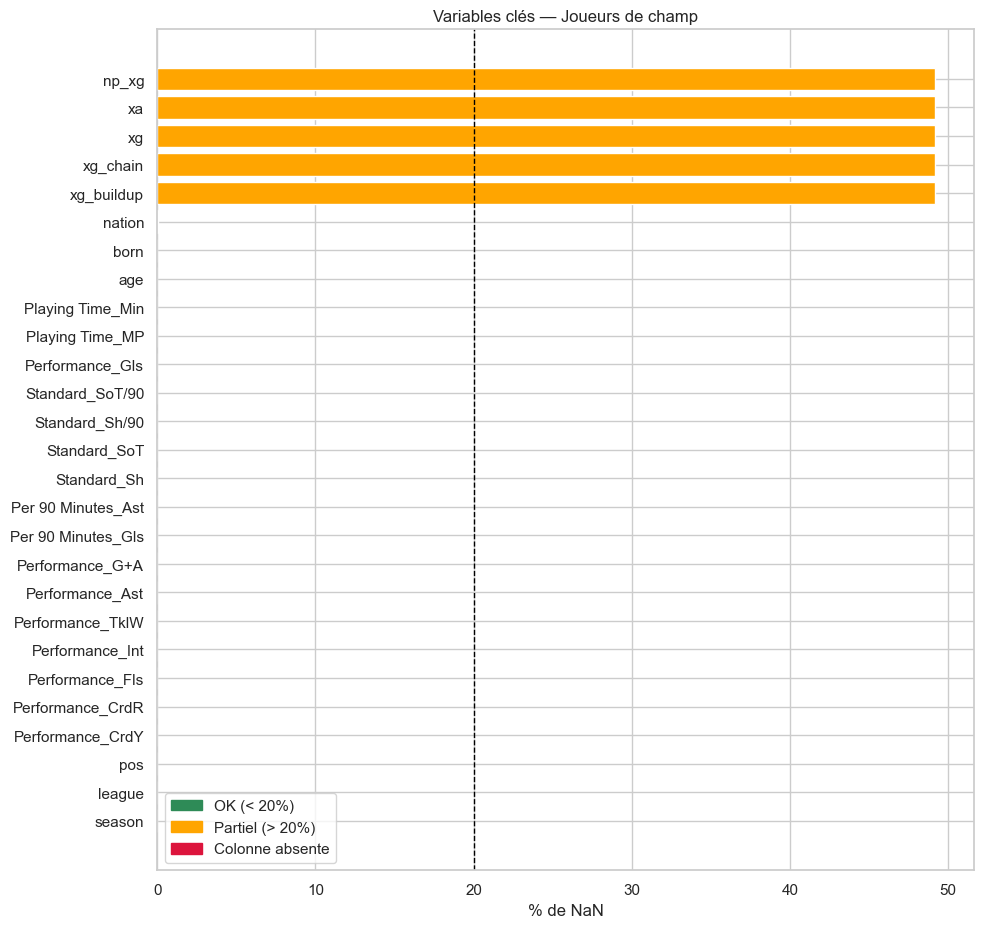

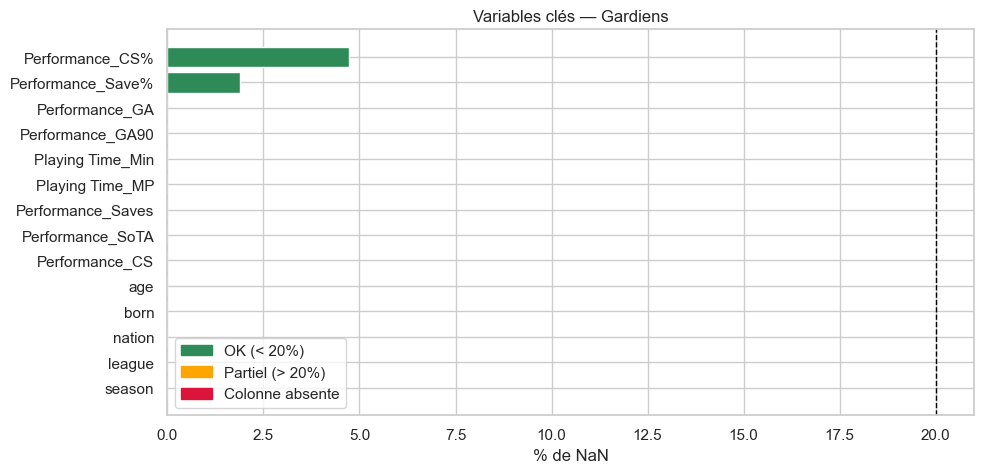

In [43]:
# Couverture des variables clés
key_coverage_field = audit_key_columns_missing(
    df_field, KEY_COLS_FIELD, title="Variables clés — Joueurs de champ"
)
key_coverage_gk = audit_key_columns_missing(
    df_gk, KEY_COLS_GK, title="Variables clés — Gardiens"
)

#### B2.4 : Couverture temporelle et géographique

L'équilibre du dataset par saison et par ligue est crucial pour éviter les biais d'entraînement.
On perçoit que le volume de joueurs est stable entre les saisons **2021 et 2026**, avec environ 500 à 600 joueurs par championnat majeur. La **Serie A** et **La Liga** présentent systématiquement les effectifs les plus grands dans le dataset.

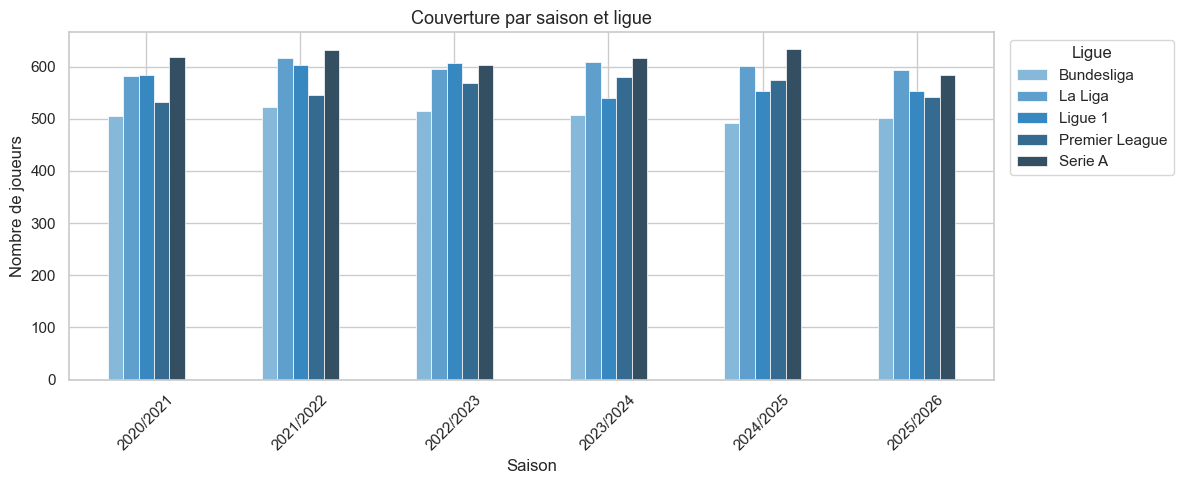

league     Bundesliga  La Liga  Ligue 1  Premier League  Serie A
season                                                          
2020/2021         505      582      584             532      619
2021/2022         523      617      604             546      632
2022/2023         515      596      606             569      603
2023/2024         507      609      540             580      616
2024/2025         492      601      553             574      634
2025/2026         502      593      553             542      584


In [44]:
# Couverture temporelle et géographique
coverage_season = audit_coverage_by_season(df_soccerdata)

#### B2.5 : Distributions des métriques clés

Nous analysons certaines données pour percevoir si nous avons besoin de les normaliser ou de traiter des valeurs aberrantes.


* **Temps de jeu :** La médiane se situe à **1079 minutes**, avec une forte concentration de joueurs ayant peu joué.
* **Performance :** Les buts (`Gls`) et passes décisives (`Ast`) ont une médiane très basse (1.0 pour les buts), illustrant la rareté de la performance offensive de haut niveau.

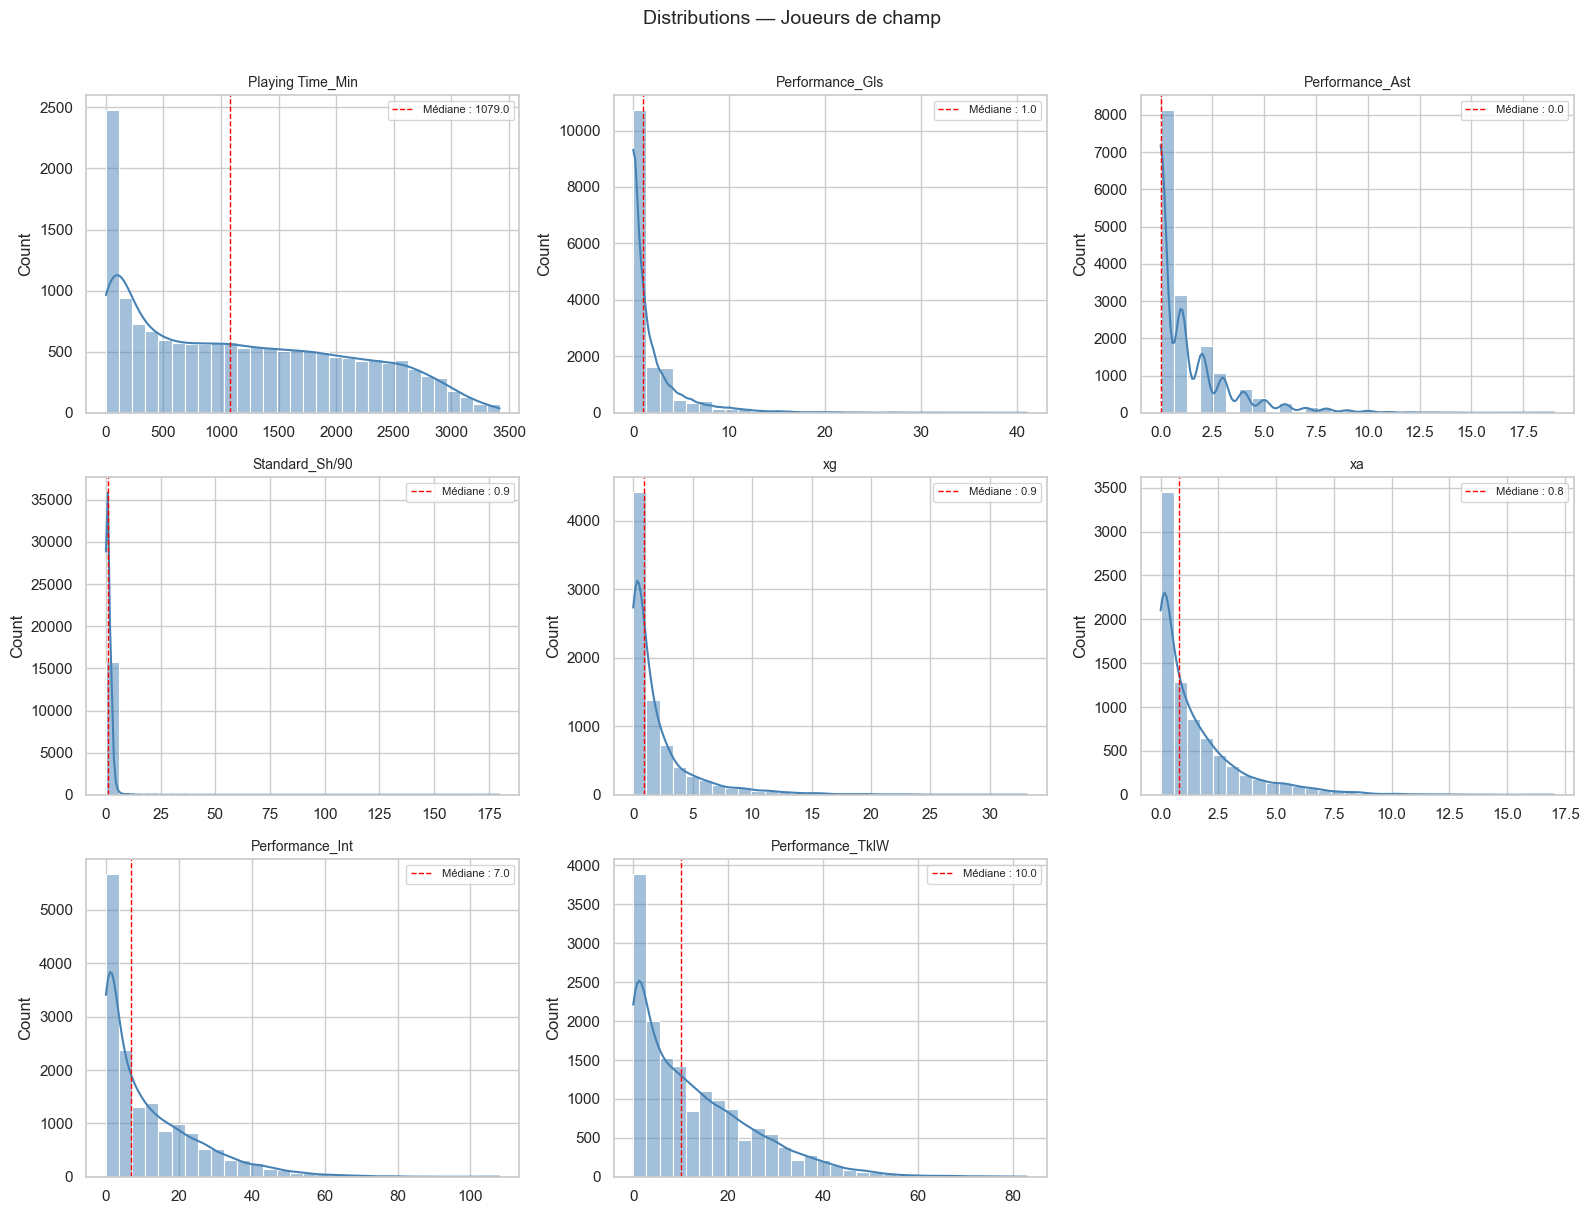

In [45]:
# Distributions des métriques clés
audit_distributions(df_field, title="Distributions — Joueurs de champ")

#### B2.6 : Diagnostic spécifique pour les données xG

Pourquoi les xG affichent-ils un taux de manquants élevé ?

* La saison **2122** présente une absence totale (100% NaN) de données `xg`, `xa` et `np_xg`. 
* Pour les autres saisons, le taux de manquants oscille entre **37% et 42%**. Peut-être est-ce dû au fait que certains joueurs ne tirent jamais. 


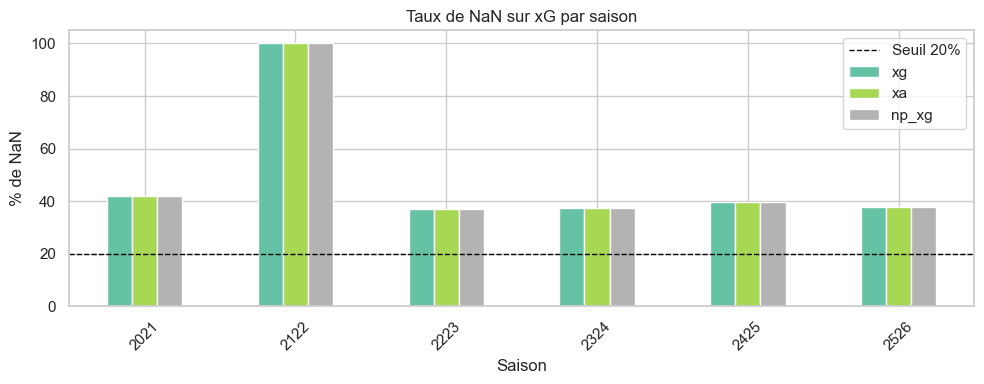

           xg     xa  np_xg
season                     
2021     41.9   41.9   41.9
2122    100.0  100.0  100.0
2223     37.0   37.0   37.0
2324     37.5   37.5   37.5
2425     39.8   39.8   39.8
2526     37.7   37.7   37.7


In [46]:
# Diagnostic des données xG
xg_missing = audit_xg_missing_by_season(df_field)

#### B2.7 : Répartition des postes


Le graphique ci-dessus présente la distribution des joueurs selon leur secteur de jeu :


* Les **milieux de terrain** représentent près de la moitié de l'effectif total.
* Le bloc défensif (**défenseurs** et **gardiens**) cumule 34,0 % des joueurs.
* Les **attaquants** constituent un peu plus d'un cinquième du groupe.

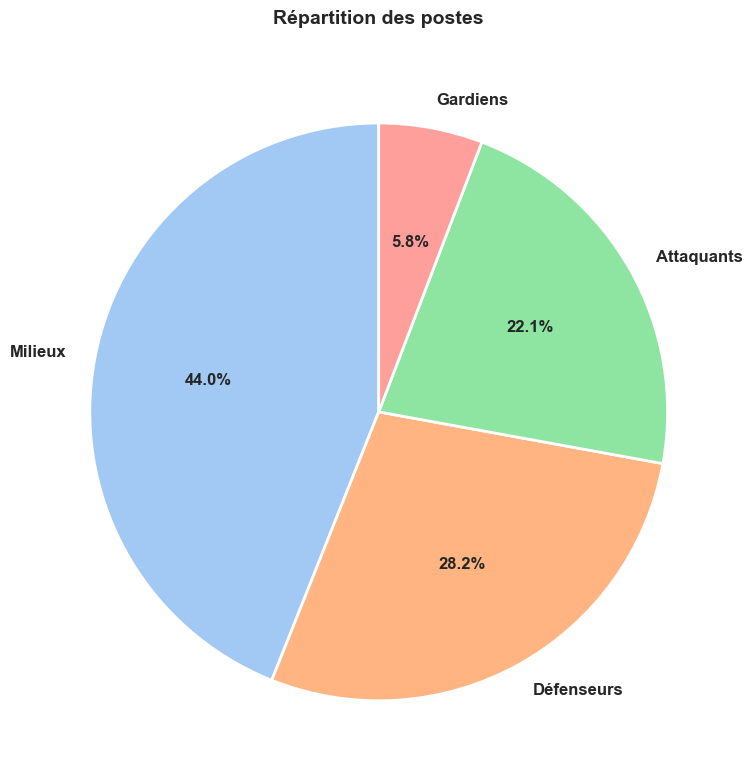

pos
Milieux       9266
Défenseurs    5937
Attaquants    4648
Gardiens      1225
Name: count, dtype: int64

In [47]:
plot_repartition_postes(df_soccerdata, title="Répartition des postes")

### B3 : Les données de blessures Transfermarkt

#### B3.1 Formatage et types de données

* L'intégralité des variables issues du scraping est actuellement stockée au format texte (`str`), hormis la variable `player_id`.
* Les métriques temporelles (`Debut`, `Fin`) et de gravité (`Jours`, `Matchs_Manques`) ne sont donc pas exploitables mathématiquement en l'état.
* Un parsing rigoureux est nécessaire pour convertir les dates en objets `datetime` et extraire les valeurs numériques.

In [54]:
# Chargement du dataset et vérification des types
df, info_types = load_and_check_types('../data/dataset_blessures.csv')

,Type
player_id,int64
Nom,str
Club_Blessure,str
Saison,str
Blessure,str
Debut,str
Fin,str
Jours,str
Matchs_Manques,str


#### B3.2 Analyse des valeurs manquantes et cohérence temporelle

* Le dataset est globalement très sain. Nous ne déplorons qu'**une seule date de début manquante**.
* **Le cas des dates de fin :** Ces absences de données se concentrent principalement sur la saison en cours. Il ne s'agit pas d'une erreur de collecte, mais de **blessures actuelles** (joueurs actuellement à l'infirmerie).
* La distribution temporelle est stable, affichant un nombre de blessures équivalent et homogène sur toutes les saisons analysées. Cela garantit l'absence de biais statistique lié à une saison en particulier.

In [55]:
# Vérification des valeurs manquantes et des doublons
missing_df, duplicates = check_missing_and_duplicates(df)

Taux de NA


,Manquants (Absolus),Manquants (%)
player_id,0,0.000000
Nom,0,0.000000
Club_Blessure,0,0.000000
Saison,0,0.000000
Blessure,0,0.000000
Debut,1,0.004865
Fin,69,0.335701
Jours,0,0.000000
Matchs_Manques,0,0.000000



Nombre de lignes doublons : 0


In [ ]:
# Analyse de statistiques descriptives
stats_desc, blessures_saison = analyse_distributions(df)


Volume de blessures par saison
        Nombre_de_Blessures
Saison                     
20/21                  3258
21/22                  3566
22/23                  3183
23/24                  3345
24/25                  3575
25/26                  3627

Statistiques descriptives des variables clés
          Jours_num  Matchs_Manques_num
count  20553.000000        19232.000000
mean      35.151170            5.329711
std       57.388937            7.798921
min        1.000000            1.000000
25%        8.000000            1.000000
50%       17.000000            3.000000
75%       37.000000            6.000000
max     1503.000000          145.000000


#### B3.3 Profil des distributions

* La grande majorité des indisponibilités sont de **courte durée** (alertes musculaires légères, maladies). Elles contrastent fortement avec les quelques valeurs aberrantes représentant les blessures de longue durée (ruptures de ligaments, fractures).
* Ces deux profils devront être traités différemment. Une indisponibilité de 5 jours n'impacte pas la valeur marchande de la même manière qu'une saison blanche, car le niveau au retour de blessure peut être assez aléatoire.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\exploration\blessures.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_temp, y='Blessure', order=top_blessures, ax=axes[1], palette='Blues_r')
c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\exploration\blessures.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_temp, y='Club_Blessure', order=top_clubs, ax=axes[2], palette='Oranges_r')


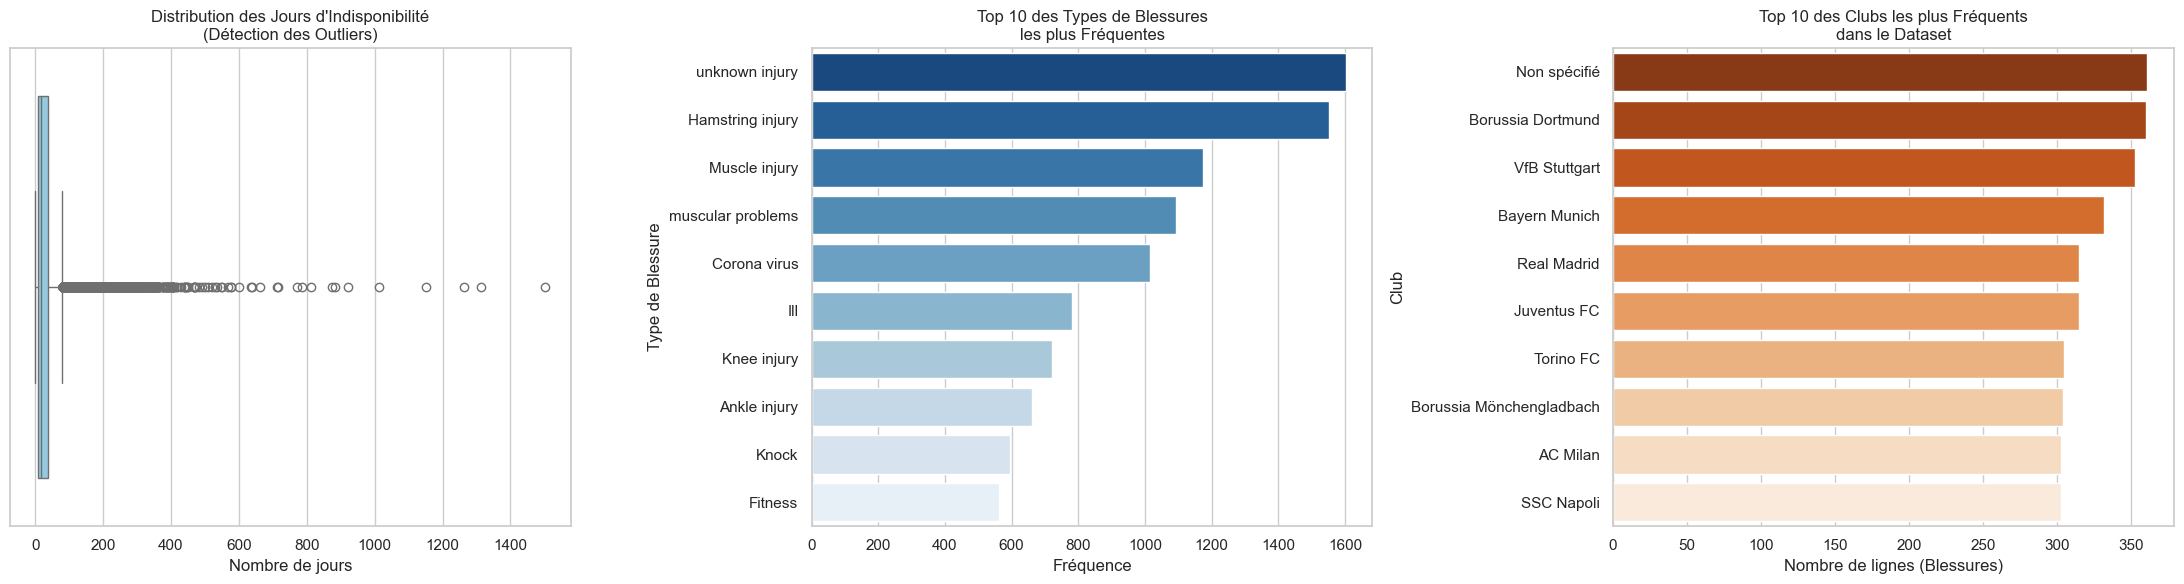

In [57]:
# Différents affichages
fig = plot_injury_distributions(df)

#### B3.4 Le problème des clubs « Non spécifiés »

Un volume significatif de lignes attribue la mention **"Non spécifié"** à la colonne `Club_Blessure`. L'analyse de ces blessures devra donc être réalisée avec précaution.

In [58]:
# On filtre en ne gardant que les joueurs ayant un club spécifié
df = df[df['Club_Blessure'] == 'Non spécifié']

# Différents affichages
len(df)

361

### B4 : Les données dollectives de football-data.co.uk

#### B4.1 : Source des données et traçabilité

Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via le site football-data.co.uk.

**Dataset :** [Historical Football Results and Betting Odds Data](https://www.football-data.co.uk/data.php)

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour de la dernière saison, car les résultats étant publiés au fur et à mesure des saisons, les saisons précédentes sont donc déjà complétées.

In [78]:
# Vérification des mises à jour
df_status = check_football_data_updates(season="2526")

# Affichage élégant
display(df_status)

Vérification des mises à jour (Saison 2526)...



,Compétition,Code,Dernière mise à jour
0,Premier League,E0,"Mon, 25 May 2026 19:01:01 GMT"
1,Liga,SP1,"Mon, 25 May 2026 19:01:02 GMT"
2,Serie A,I1,"Mon, 25 May 2026 19:01:02 GMT"
3,Ligue 1,F1,"Mon, 22 Jun 2026 10:01:59 GMT"
4,Bundesliga,D1,"Tue, 19 May 2026 09:06:12 GMT"


#### B4.2 Nettoyage des données

Le dataset a été filtré pour ne conserver que les indicateurs de performance et les cotes principales.

Ainsi, nous supprimons les colonnes qui nous sont inutiles. Les données sont prêtes pour être analysées.

In [79]:
# On charge avec low_memory=False car le fichier est large et hétérogène
df_collective = pd.read_csv("../data/football_data.csv", low_memory=False)

# Nettoyage via la fonction
df_collective = process_football_data(df_collective)

Audit Football-Data :
    Nombre de colonnes initiales : 163
    Nombre de colonnes après élagage : 25
    Matchs validés : 10734


#### B4.3 Intégrité des données

L'audit de qualité final confirme la robustesse du dataset **Football-Data** après traitement. Les données sont structurellement saines et prêtes pour la phase de modélisation.

En effet, une seule ligne (1 match) présente des valeurs manquantes sur l'ensemble des statistiques de jeu (Tirs, Corners, Fautes, Cartons). De plus, aucun doublon n'a été détecté.

Aucune erreur de score ou de résultat final n'a été détecté non plus.

Le dataset est considéré comme propre. L'absence totale d'erreurs de résultat et de doublons assure que le modèle ne subira aucun biais lié à des erreurs de saisie humaine dans la source de données.

In [80]:
# Vérification des valeurs manquantes et des doublons

df_na = audit_data_quality(df_collective)

Analyse qualité :
    Doublons détectés : 0
Colonnes avec données manquantes :
Variable  Nombre de NA
      HS             1
      AS             1
     HST             1
     AST             1
      HF             1
      AF             1
      HC             1
      AC             1
      HY             1
      AY             1
      HR             1
      AR             1
   B365H             5
   B365D             5
   B365A             5
    AvgH             1
    AvgD             1
    AvgA             1


In [81]:
# Lancement de l'audit final sur le dataframe nettoyé

audit_football_data_coherence(df_collective)

Audit de cohérence terminé :
    Erreurs de score (négatifs)  : 0
    Erreurs de résultat (FTR)    : 0
    Anomalies sur les cotes      : 0
    Matchs en double             : 0
Intégrité des données parfaite.


{'score_errors': 0,
 'result_errors': 0,
 'odd_errors': 0,
 'duplicates': np.int64(0)}

#### B4.4 Analyse de la couverture et des ligues

Ce dernier contrôle permet de valider l'équilibre du dataset et la profondeur historique disponible pour l'entraînement du modèle.

Le dataset couvre la période sélectionnée initialement. Cette durée est idéale pour capturer la saisonnalité et l'évolution à long terme des performances des clubs.


Les données sont équitablement réparties entre les **5 grands championnats européens (Big Five)**. La différence de volume (Bundesliga et Ligue 1) s'explique structurellement par le passage à **18 clubs** (34 journées contre 38 pour les autres ligues). Cette répartition reflète la réalité du calendrier européen.


Les données sont **synchronisées, nommées et équilibrées**. Nous disposons d'une base solide de plus de 5 000 matchs pour débuter nos analyses statistiques.

In [82]:
# Couverture temporelle du dataset

check_temporal_coverage(df_collective, 'Date')

Couverture temporelle [Date] :
    Début : 21/08/2020
    Fin   : 24/05/2026
    Durée : 2102 jours


(Timestamp('2020-08-21 00:00:00'), Timestamp('2026-05-24 00:00:00'))

In [83]:
# Couverture géographique du dataset

df_collective = analyse_league_distribution(df_collective, league_col='Div')

Répartition par Compétition :
Div
Serie A           2280
Premier League    2280
Liga              2280
Ligue 1           2058
Bundesliga        1836
Total Matchs : 10734


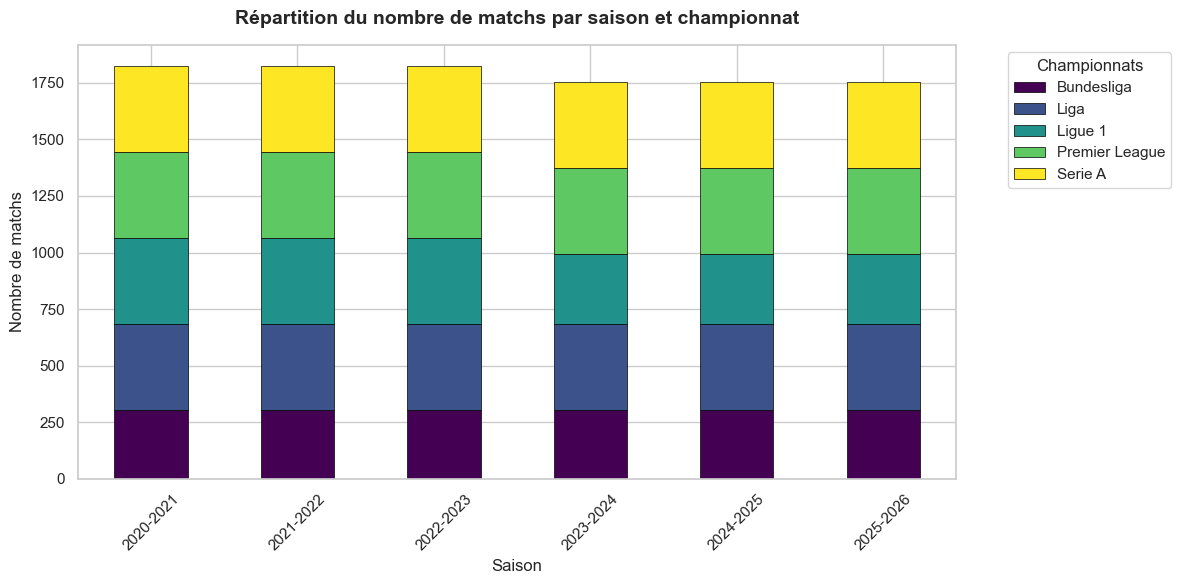

Div,Bundesliga,Liga,Ligue 1,Premier League,Serie A
Saison,,,,,
2020-2021,306,380,380,380,380
2021-2022,306,380,380,380,380
2022-2023,306,380,380,380,380
2023-2024,306,380,306,380,380
2024-2025,306,380,306,380,380
2025-2026,306,380,306,380,380


In [84]:
plot_football_seasons_distribution(df_collective, date_col='Date')

# Exploration des annexes

## 4. FBref - data qualité

### 0. Source des données et traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Players Stats (2025-2026)](https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2025-2026)
* **Identifiant :** `hubertsidorowicz/football-players-stats-2025-2026`

In [65]:
# L'identifiant du Kaggle
identifiant = 'hubertsidorowicz/football-players-stats-2025-2026'

# La date de dernière mise à jour
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : hubertsidorowicz/football-players-stats-2025-2026
Dernière mise à jour : 2026-06-01 20:07:37.110000


### 1. Filtrage de représentativité

Le dataset FBref brut contient l'intégralité des joueurs ayant foulé la pelouse, même pour quelques secondes. Pour garantir la robustesse statistique de notre modèle, un filtrage sur le temps de jeu est impératif.

Nous avons fixé un minimum de **450 minutes jouées** (l'équivalent de 5 matchs complets). Ce filtre réduit le dataset de **30.7%**, passant de 2 751 à 1 907 joueurs. Bien que la perte de données semble importante, elle est nécessaire pour éliminer le bruit statistique.

Avant filtrage, des joueurs comme *Marin Ljubicic* affichaient un ratio de **8.18 buts / 90 min** (car il a marqué 2 buts en seulement 22 minutes). En conservant ces profils, on prendrait en compte des corrélations erronées, pensant que l'efficacité est décorrélée du temps de jeu réel.

Enfin, nous avons isolé **1 777 joueurs de champ** et **130 gardiens de but**. Cette séparation est fondamentale car les métriques de performance (tacles, buts vs arrêts, clean sheets) ne sont pas comparables mathématiquement.

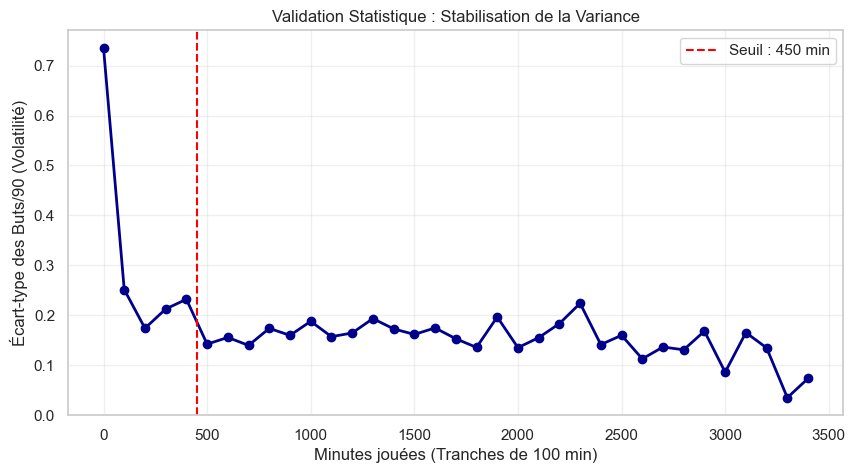

Preuve mathématique : Réduction du bruit de 69.9%
FILTRAGE TERMINÉ
- Joueurs initiaux : 2839
- Joueurs conservés : 1999 (Soit 1860 joueurs de champ)


In [66]:
# Chargement initial
df_fbref = pd.read_csv("../data/fbref_datasets/players_data-2025_2026.csv")

# Appel de la fonction
df_field, df_keepers = process_fbref_performance(df_fbref, min_minutes_played=450)

### 2. Analyse des valeurs manquantes

Le dataset FBref original est une agrégation complexe de plusieurs rapports (Standard, Shooting, Passing, etc.), ce qui génère une redondance massive d'informations et de nombreuses cellules vides.

Nous pouvons donc percevoir un grand nombre de variables ayant au moins 80% de valeurs manquantes.


La majorité des variables affichant plus de 80% de valeurs manquantes sont préfixées par _keeper (ex: GA, Saves, Save%, CS). Cela s'explique par le fait que ces statistiques ne concernent que les gardiens de but, qui ne représentent qu'une petite partie des joueurs présents dans le dataset global.

De plus, certaines colonnes comme PKsv (Penalties saved) ou PKm (Penalties missed) sont quasi vides car elles dépendent d'événements rares qui ne se produisent pas pour la majorité des joueurs au cours d'une saison.

Enfin, sur le Top 25 des variables les plus incomplètes, 24 dépassent le seuil critique de 80% de données manquantes, rendant ces colonnes inexploitables pour un modèle de machine learning global sans un traitement spécifique (segmentation par poste).

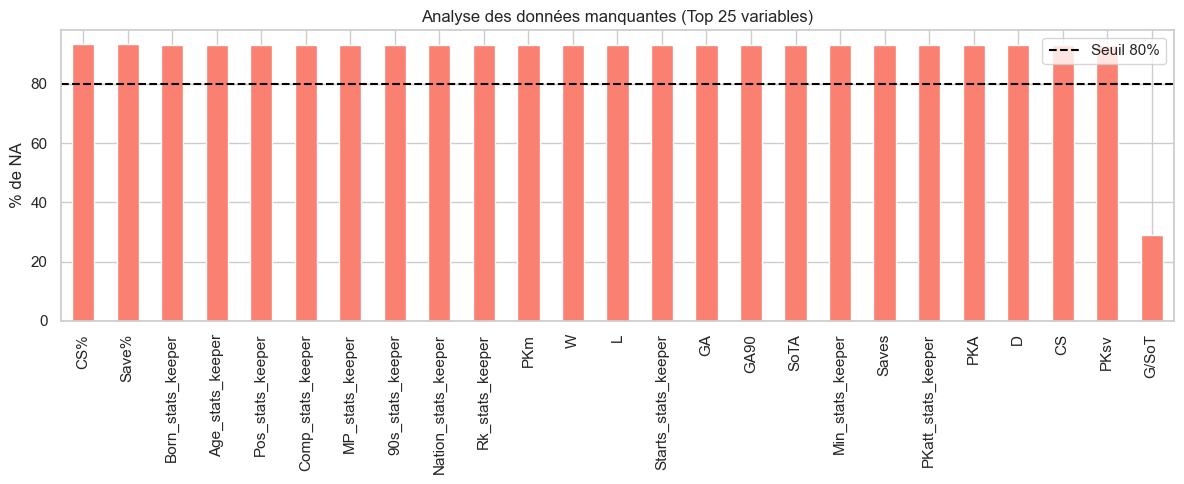

In [67]:
# Utilisation de la fonction sur tes joueurs de champ déjà filtrés
prune_fbref_columns(df_fbref, threshold=0.80)

### 3. Intégrité et unicité

Dans le dataset FBref, un joueur ayant changé de club ou ayant été prêté durant la saison apparaît sur plusieurs lignes (une entrée par club). 

Sans traitement, ces joueurs sont comptabilisés comme deux entités distinctes avec des statistiques partielles. Par exemple, **Simon Adingra** possédait deux lignes (une avec Sunderland, une avec Monaco) avec des volumes de jeu et des buts différents.

Nous avons identifié **26 joueurs** présentant ce cas de figure. Afin de garantir la représentativité de la performance, nous avons appliqué une règle de sélection stricte : seule la ligne présentant le **temps de jeu le plus élevé** est conservée.

Le volume est passé de 2761 à **2609 lignes**. Cette étape assure l'atomicité du dataset : **un joueur = une ligne**.

In [68]:
# On applique la résolution sur le dataset nettoyé
df_fbref_final = resolve_player_duplicates(df_fbref)

Joueurs avec plusieurs lignes (transferts/doublons) : 151
Bilan de l'unicité :
- Lignes traitées : 2839
- Lignes après dédoublonnage : 2687
- 'Doublons de transfert' supprimés : 152
----------------------------------------


### 4. Normalisation des Types et Formats

Pour que les données de performance soient exploitables par nos algorithmes et compatibles avec le dataset Transfermarkt, nous avons procédé à une normalisation structurelle.

En ce qui concerne l'âge, le format textuel de FBref (ex: `27-125`) a été transformé en format **float64**. Cette conversion est indispensable pour inclure l'âge comme variable quantitative dans nos futurs modèles de régression.

Les valeurs manquantes ont quant-à-elles été remplacés par **0**. Dans le contexte du football, une absence de donnée sur un tir ou une passe signifie que l'action n'a pas eu lieu, et non que l'information est inconnue.

Ainsi, le dataset final ne contient plus **aucune valeur manquante (0 NaN)** sur les 47 colonnes conservées, garantissant une stabilité totale pour les calculs matriciels à venir.

In [69]:
# Application de la normalisation sur ton dataset unique
df_fbref_final = normalize_fbref_formats(df_fbref_final)

# Vérification rapide
print(f"Format final de la colonne Age : {df_fbref_final['Age'].dtype}")

Normalisation des formats terminée.
- Colonnes numériques imputées (0) : 85
- Colonnes texte imputées (Unknown) : 17
- Valeurs manquantes totales restantes : 0
Format final de la colonne Age : float64


### 5. Cohérence statistique

La dernière étape de notre protocole de nettoyage consiste à valider les valeurs extrêmes pour s'assurer qu'elles reflètent la réalité sportive et non une anomalie de saisie.

L'analyse des boxplots révèle des outliers significatifs sur le nombre de buts et de tirs. Après vérification, ces points correspondent aux "Top Players" mondiaux. Ces données sont conservées car elles sont essentielles pour que l'IA apprenne à valoriser ces joueurs atypiques.

Au niveau d l'âge, une valeur aberrante a été détectée (0 année). Cela est probablement dû à une valeur manquantes remplacée par un 0. La population étudiée est alors hormis cet individu cohérente avec les standards du football professionnel.

Enfin, en l'absence du filtre initial de 450 minutes, les ratios par 90 minutes (Gls/90, Sh/90) ne sont pas stabilisés et présentent des pics mathématiques artificiels.

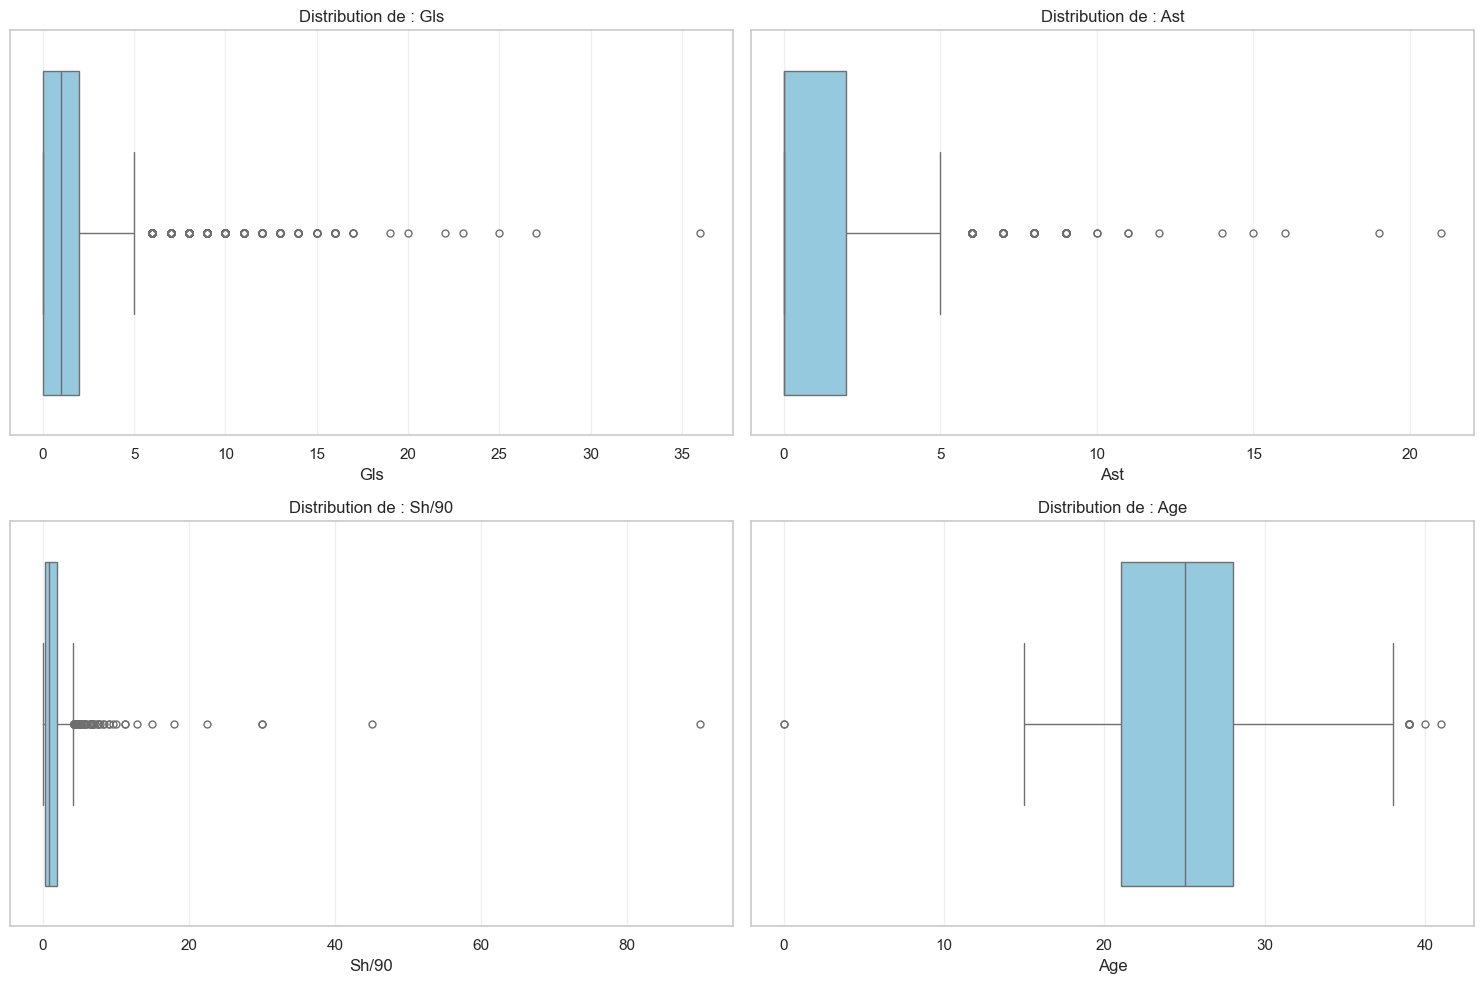

Top 5 'Outliers' Performance (Gls) :
              Player            Squad  Gls   Min
1319      Harry Kane    Bayern Munich   36  2377
1104  Erling Haaland  Manchester City   27  2953
1701   Kylian Mbappé      Real Madrid   25  2599
1847    Vedat Muriqi         Mallorca   23  3128
2580     Igor Thiago        Brentford   22  3282
----------------------------------------


In [70]:
# Lancement de l'audit sur ton dataset nettoyé
audit_fbref_outliers(df_fbref_final, metrics=['Gls', 'Ast', 'Sh/90', 'Age'])

## 5. Statsbomb - data qualité

### 1. Bilan des données StatsBomb

L'analyse des fichiers `.feather` permet de valider la structure des données de performance tactique. Nous analysons en effet 3464 matches qui peuvent présenter des incohérences dans les bases de données.

Nous ne trouvons cependant aucun doublon dans les données. Cependant, pour le moment, nous ne trouvons pas les compositions d'équipe peu importe le match. Les variables comparées sont sans doute légèrement différentes, il faudra donc régler ce problème pour trouver les joueurs présents dans les matches.



Malgré le problème de liaison, le volume par ligue est significatif et couvre bien le "Big Five" européen :

* **La Liga** : 868 matchs
* **Ligue 1** : 435 matchs
* **Premier League** : 418 matchs
* **Serie A** : 381 matchs
* **Bundesliga** : 340 matchs

In [71]:
# Définition du chemin (adapte selon ton architecture)
folder = Path("../data/statsbomb_datasets/data")

# 1. Chargement des fichiers Feather
df_sb_matches = pd.read_feather(folder / "all_matches.feather")
df_sb_lineups = pd.read_feather(folder / "all_lineups.feather")
df_sb_competitions = pd.read_feather(folder / "competitions_statsbomb.feather")

# 2. Exécution de l'Audit
stats_report = audit_statsbomb_data(df_sb_matches, df_sb_lineups)

AUDIT STATSBOMB
-------------------------------------------
• Matchs   : 3961 lignes | Doublons : 0
• Lineups  : 161958 lignes | Doublons : 0
• Intégrité: 3961 match(s) sans composition d'équipe
-------------------------------------------
Aucune valeur manquante sur les identifiants clés.

Top 5 Compétitions (StatsBomb) :
competition.competition_name
La Liga                    867
FA Women's Super League    457
Ligue 1                    435
Premier League             418
Serie A                    381
Name: count, dtype: int64
-------------------------------------------


### 2. Analyse de la couverture temporelle

Cette analyse valide la profondeur historique du dataset **StatsBomb** après application d'un filtre analysant les matches à partir de 2020.


Le dataset filtré couvre plus de **5 ans** de données footballistiques, de juillet 2020 à juillet 2025, permettant de capturer les évolutions tactiques récentes.

Bien que le nombre total de matchs (760) soit inférieur à d'autres datasets, la qualité "événementielle" de StatsBomb compense cette quantité par une densité d'information supérieure (xG, pressions, positions).


On observe une accélération de la collecte de données sur les saisons civiles et les exercices récents.

| Saison | Nombre de Matchs |
| :--- | :---: |
| **2023** | 122 |
| **2024** | 83 |
| **2023/2024** | 34 |
| **2022/2023** | 32 |
| **2025** | 31 |

Il faudrait cependant normaliser les noms des saisons pour en tirer des conclusions.

In [72]:
# Analyse temporelle
sb_start, sb_end = check_statsbomb_temporal_coverage(df_sb_matches)

COUVERTURE TEMPORELLE STATSBOMB (Depuis 01/07/2020)
-------------------------------------------
• Premier match : 05/07/2020
• Dernier match  : 27/07/2025
• Étendue        : 1848 jours (env. 5.1 ans)
• Nb de matchs   : 1531
-------------------------------------------

Matchs par Saison :
season.season_name
2025          31
2024          83
2023/2024    668
2023         259
2022/2023     32
Name: count, dtype: int64


### 3. Analyse Graphique StatsBomb


Le dataset est dominé par **La Liga**, suivie d'un volume équilibré pour les autres ligues du **Big Five** (Ligue 1, Premier League, Serie A, Bundesliga). La présence de compétitions internationales assure cependant une bonne diversité.


La distribution des buts suit une **loi de Poisson** cohérente : généralement, il y a 1 but par équipe et la courbe des scores à domicile est légèrement plus élevée et étendue que celle à l'extérieur. Les scores élevés sont rares, confirmant l'absence d'anomalies majeures.


Les données semblent alors **statistiquement saines**. La distribution des buts valide la fiabilité des résultats pour la modélisation.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\exploration\statsbomb.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_matches, y='competition.competition_name',


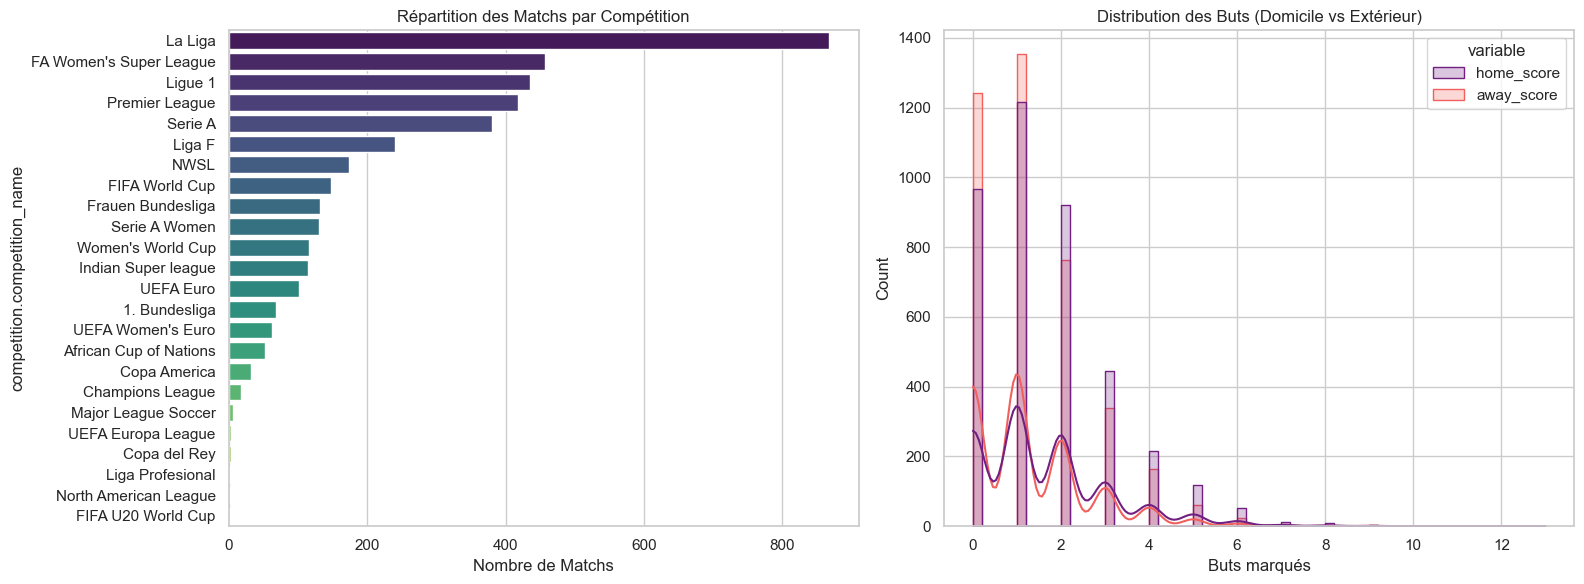

In [73]:
# 1. Visualisation des compétitions et des scores
plot_statsbomb_distributions(df_sb_matches)